# Parameter Recovery: Forward Simulation from Posterior Means

This notebook tests parameter recovery for the aDDM empirical model.
The workflow is:
1. Load a saved trace (Monkey 1)
2. Extract posterior means of (eta, kappa, a, b, x0)
3. Forward-simulate a synthetic dataset from those parameter values using the Cython simulator,
   keeping the empirical fixation structure (sacc, length_data, r1, r2, flag)
4. Fit the same PyMC model to the simulated data
5. Compare recovered posteriors to the ground-truth posterior means

In [1]:
import os
import sys
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor.tensor as pt
from pytensor.graph.op import Op

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely
from efficient_fpt.addm import _build_mu_data_padded
from efficient_fpt.addm_simulator_cy import simulate_addm_batch_cy

## Configuration

In [2]:
sigma    = 1.0   # Fixed noise (unidentifiable with other params)
max_d    = 4     # Max fixation stages

TRUNC_NUM   = 6
N_DRAWS     = 500
N_TUNE      = 500
N_CHAINS    = 3
RANDOM_SEED = 42

TRACE_PATH  = "/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk1.nc"
DATA_PATH   = "/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_1.csv"

SIM_SEED    = 7   # RNG seed for the forward simulation
SIM_DT      = 1e-4

## Helper functions (copied from empirical_test_refactored)

In [3]:
# def preprocess_monkey_data(df, max_d):
#     DATA_TYPE = np.float64
#     df = df.sort_values(by='trialNum', ascending=True)

#     r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
#     r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

#     third_present = df['thirdFixLat'].notna().to_numpy()
#     length_data = np.where(third_present, 3, 2).astype(np.int32)

#     t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
#     firstfixDur  = df['firstFixDur'].to_numpy(dtype=DATA_TYPE)
#     secondfixDur = df['secondFixDur'].to_numpy(dtype=DATA_TYPE)

#     sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
#     sacc[:, 0] = 0.0
#     sacc[:, 1] = firstfixDur
#     sacc[third_present, 2] = firstfixDur[third_present] + secondfixDur[third_present]

#     first_is_left = df['firstIsLeft'].to_numpy().astype(int)
#     flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

#     rt = df["liftRT"].to_numpy(dtype=DATA_TYPE)

#     left_chosen = df["leftChosen"].to_numpy().astype(int)
#     choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

#     return dict(r1=r1, r2=r2, rt=rt, choice=choice,
#                 flag_data=flag_data, sacc=sacc, length_data=length_data)


def preprocess_monkey_data(df, max_d):
    DATA_TYPE = np.float64
    df = df.sort_values(by='trialNum', ascending=True)

    r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
    r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

    third_present = df['thirdFixLat'].notna().to_numpy()
    length_data = np.where(third_present, 3, 2).astype(np.int32)

    t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
    t1 = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
    t2 = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

    sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
    sacc[:, 0] = 0.0
    sacc[:, 1] = t1 - t0
    sacc[third_present, 2] = t2[third_present] - t0[third_present]

    first_is_left = df['firstIsLeft'].to_numpy().astype(int)
    flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

    rt_raw = df["liftRT"].to_numpy(dtype=DATA_TYPE)
    rt = rt_raw - t0

    left_chosen = df["leftChosen"].to_numpy().astype(int)
    choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

    return dict(r1=r1, r2=r2, rt=rt, choice=choice,
                flag_data=flag_data, sacc=sacc, length_data=length_data)


def make_jax_arrays(data, max_d):
    jax_sacc = jnp.array(data['sacc'])
    jax_d    = jnp.array(data['length_data'])
    jax_sacc_safe = vmap(
        lambda s, d: pad_sacc_array_safely(s, d, max_d)
    )(jax_sacc, jax_d)
    return dict(
        rt       = jnp.array(data['rt']),
        choice   = jnp.array(data['choice']),
        d        = jax_d,
        r1       = jnp.array(data['r1']),
        r2       = jnp.array(data['r2']),
        flag     = jnp.array(data['flag_data']),
        sacc_safe= jax_sacc_safe,
    )


def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num
    )
    return jnp.log(jnp.maximum(fptd, 1e-300))


def make_jax_likelihood(jax_data, sigma, max_d, trunc_num):
    def loglik_batch(eta, kappa, a, b, x0):
        per_trial = vmap(
            lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
                rt, choice, d, r1, r2, flag, sacc_safe,
                eta, kappa, a, b, x0, sigma, max_d, trunc_num,
            )
        )(
            jax_data['rt'], jax_data['choice'], jax_data['d'],
            jax_data['r1'], jax_data['r2'], jax_data['flag'],
            jax_data['sacc_safe'],
        )
        return jnp.sum(per_trial)

    loglik_jit  = jit(loglik_batch)
    grad_loglik = jit(grad(loglik_batch, argnums=(0, 1, 2, 3, 4)))
    return loglik_jit, grad_loglik


class LogLikeJAXGrad(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


class LogLikeJAX(Op):
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        outputs[0][0] = np.array(float(self.loglik_fn(eta, kappa, a, b, x0)), dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,)  = inputs
        (g_out,)  = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


# JAX dispatch registrations — required for nuts_sampler="numpyro"
from pytensor.link.jax.dispatch import jax_funcify

@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return jnp.stack(grad_fn(eta, kappa, a, b, x0))
    return grad_jax


def make_pymc_model(loglike_op, M):
    with pm.Model() as model:
        eta     = pm.Beta("eta",   alpha=2.0, beta=2.0, initval=0.1)
        kappa   = pm.Gamma("kappa", alpha=2.0, beta=4.0, initval=1.15)
        # a_param = pm.Gamma("a",     alpha=4.0, beta=2.0, initval=3.0)
        a_param = 3.0

        b_raw   = pm.Beta("b_raw", alpha=2.0, beta=2.0)
        b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)
        # b_param = 2.0

        x0_raw  = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
        x0_param= pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)

        theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
        pm.Potential("loglik", loglike_op(theta))
    return model

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load empirical data and fitted trace

In [4]:
monk_data = pd.read_csv(DATA_PATH)
data_emp  = preprocess_monkey_data(monk_data, max_d)

trace_emp = az.from_netcdf(TRACE_PATH)

print(f"Empirical trials : {len(data_emp['rt'])}")
print(f"Trace chains/draws: {trace_emp.posterior.dims['chain']} x {trace_emp.posterior.dims['draw']}")

Empirical trials : 587
Trace chains/draws: 4 x 500


/tmp/ipykernel_3053828/3927802303.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Trace chains/draws: {trace_emp.posterior.dims['chain']} x {trace_emp.posterior.dims['draw']}")


## 2. Extract posterior means — these are the ground-truth parameters

In [5]:
TRUE_PARAMS = {
    'eta'  : float(trace_emp.posterior['eta'].mean()),
    'kappa': float(trace_emp.posterior['kappa'].mean()),
    'a'    : float(trace_emp.posterior['a'].mean()),
    'b'    : float(trace_emp.posterior['b'].mean()),
    'x0'   : float(trace_emp.posterior['x0'].mean()),
}

print("Ground-truth parameters (posterior means from empirical fit):")
for k, v in TRUE_PARAMS.items():
    print(f"  {k:6s} = {v:.6f}")

Ground-truth parameters (posterior means from empirical fit):
  eta    = 0.015413
  kappa  = 1.158869
  a      = 3.008039
  b      = 2.067908
  x0     = 0.055326


## 3. Forward-simulate a synthetic dataset

We keep the empirical fixation structure (sacc, length_data, r1, r2, flag)
and simulate new RT/choice outcomes using the Cython batch simulator.

In [6]:
eta_t   = TRUE_PARAMS['eta']
kappa_t = TRUE_PARAMS['kappa']
a_t     = TRUE_PARAMS['a']
b_t     = TRUE_PARAMS['b']
x0_t    = TRUE_PARAMS['x0']

r1  = data_emp['r1']
r2  = data_emp['r2']
sacc         = data_emp['sacc']
length_data  = data_emp['length_data']
flag_data    = data_emp['flag_data']
n_trials     = len(r1)

# Build per-trial drift arrays
mu1 = kappa_t * (r1 - eta_t * r2)
mu2 = kappa_t * (eta_t * r1 - r2)
mu_data = _build_mu_data_padded(
    mu1.astype(np.float64),
    mu2.astype(np.float64),
    length_data, flag_data, max_d,
)

# Budget Gaussian draws up to boundary-collapse time
max_t = float(data_emp['rt'].max()) + 1.0
budget_time  = min(a_t / b_t, max_t) if b_t > 0 else max_t
budget_steps = int(budget_time / SIM_DT) + 1

rng = np.random.default_rng(SIM_SEED)
gaussian_data = np.ascontiguousarray(
    rng.standard_normal((n_trials, budget_steps)), dtype=np.float64
)

print(f"Simulating {n_trials} trials  (budget_time={budget_time:.3f}s, steps={budget_steps})")

sim_rt, sim_choice = simulate_addm_batch_cy(
    np.ascontiguousarray(mu_data),
    np.ascontiguousarray(sacc),
    np.ascontiguousarray(length_data),
    sigma, a_t, b_t, x0_t,
    SIM_DT, budget_time,
    gaussian_data,
)
sim_rt     = np.array(sim_rt)
sim_choice = np.array(sim_choice)

terminated = sim_rt > 0
print(f"Terminated: {terminated.sum()} / {n_trials}  "
      f"({100*terminated.mean():.1f}%)")
print(f"Choice +1 (among terminated): {(sim_choice[terminated] == 1).mean():.3f}")

Simulating 587 trials  (budget_time=1.455s, steps=14547)
Terminated: 587 / 587  (100.0%)
Choice +1 (among terminated): 0.482


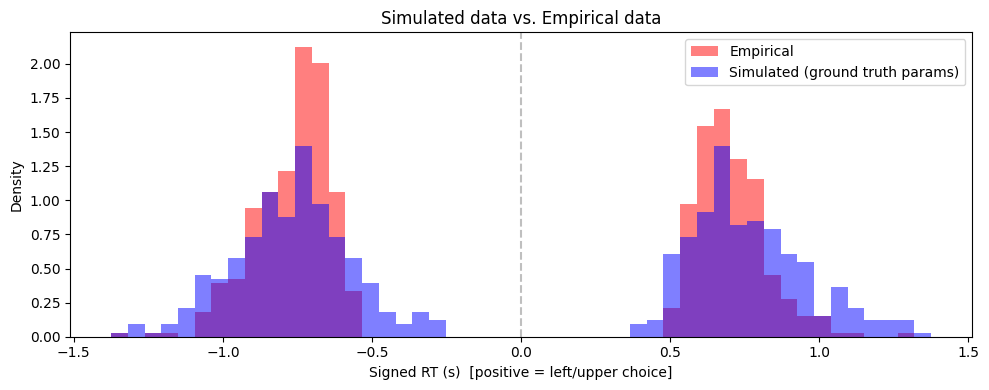

In [7]:
# Quick visual sanity check: simulated vs. empirical RT distributions
emp_rt  = data_emp['rt'] 
emp_ch  = data_emp['choice']

emp_signed = emp_rt * emp_ch
sim_signed = sim_rt[terminated] * sim_choice[terminated]

xmax = max(np.abs(emp_signed).max(), np.abs(sim_signed).max())
bins = np.linspace(-xmax, xmax, 50)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(emp_signed, bins=bins, density=True, alpha=0.5, color='red',  label='Empirical')
ax.hist(sim_signed, bins=bins, density=True, alpha=0.5, color='blue', label='Simulated (ground truth params)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Signed RT (s)  [positive = left/upper choice]')
ax.set_ylabel('Density')
ax.set_title('Simulated data vs. Empirical data')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Fit the PyMC model to the simulated data

In [8]:
# Build a data dict from the simulation output (terminated trials only)
# We keep the original fixation structure for the terminated trials.
mask = terminated

data_sim = dict(
    rt          = sim_rt[mask],
    choice      = sim_choice[mask],
    r1          = r1[mask],
    r2          = r2[mask],
    sacc        = sacc[mask],
    length_data = length_data[mask],
    flag_data   = flag_data[mask],
)

print(f"Fitting on {mask.sum()} simulated trials")

jax_data_sim = make_jax_arrays(data_sim, max_d)
loglik_sim, grad_sim = make_jax_likelihood(jax_data_sim, sigma, max_d, TRUNC_NUM)

print("Warming up JIT...")
t0_ = time.time()
_ = loglik_sim(eta_t, kappa_t, a_t, b_t, x0_t)
_ = grad_sim(eta_t, kappa_t, a_t, b_t, x0_t)
print(f"JIT warm-up: {time.time()-t0_:.1f}s")

M_sim   = float(data_sim['rt'].max())
op_sim  = LogLikeJAX(loglik_sim, grad_sim)
model_sim = make_pymc_model(op_sim, M_sim)
print("Model built.", model_sim.point_logps())

Fitting on 587 simulated trials


Warming up JIT...
JIT warm-up: 8.5s


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Model built. {'eta': np.float64(-3.02), 'kappa': np.float64(-1.55), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-545.24)}


In [9]:
print(f"Sampling | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_sim:
    t_start = time.perf_counter()
    trace_sim = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total sampling time: {t_sample:.1f}s")

Sampling | 500 draws, 500 tune, 3 chains
Started: 23:16:22


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]



Running chain 0:   0%|          | 0/1000 [00:13<?, ?it/s]

Running chain 1: 100%|██████████| 1000/1000 [01:45<00:00,  9.49it/s]

Running chain 0: 100%|██████████| 1000/1000 [01:46<00:00,  9.41it/s]


Running chain 2: 100%|██████████| 1000/1000 [01:51<00:00,  8.95it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished: 23:18:17
Total sampling time: 114.2s


## 5. Compare recovered posteriors to ground-truth

In [11]:
# params = ['eta', 'kappa', 'a', 'b', 'x0']
params = ['eta', 'kappa', 'b','x0']
print(az.summary(trace_sim, var_names=params))

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.090  0.032   0.030    0.147      0.001    0.001    1402.0     647.0   
kappa  1.105  0.029   1.048    1.154      0.001    0.001    1393.0    1054.0   
b      2.128  0.006   2.117    2.136      0.000    0.000    1251.0     909.0   
x0     0.031  0.033  -0.030    0.095      0.001    0.001    1517.0    1109.0   

       r_hat  
eta      1.0  
kappa    1.0  
b        1.0  
x0       1.0  


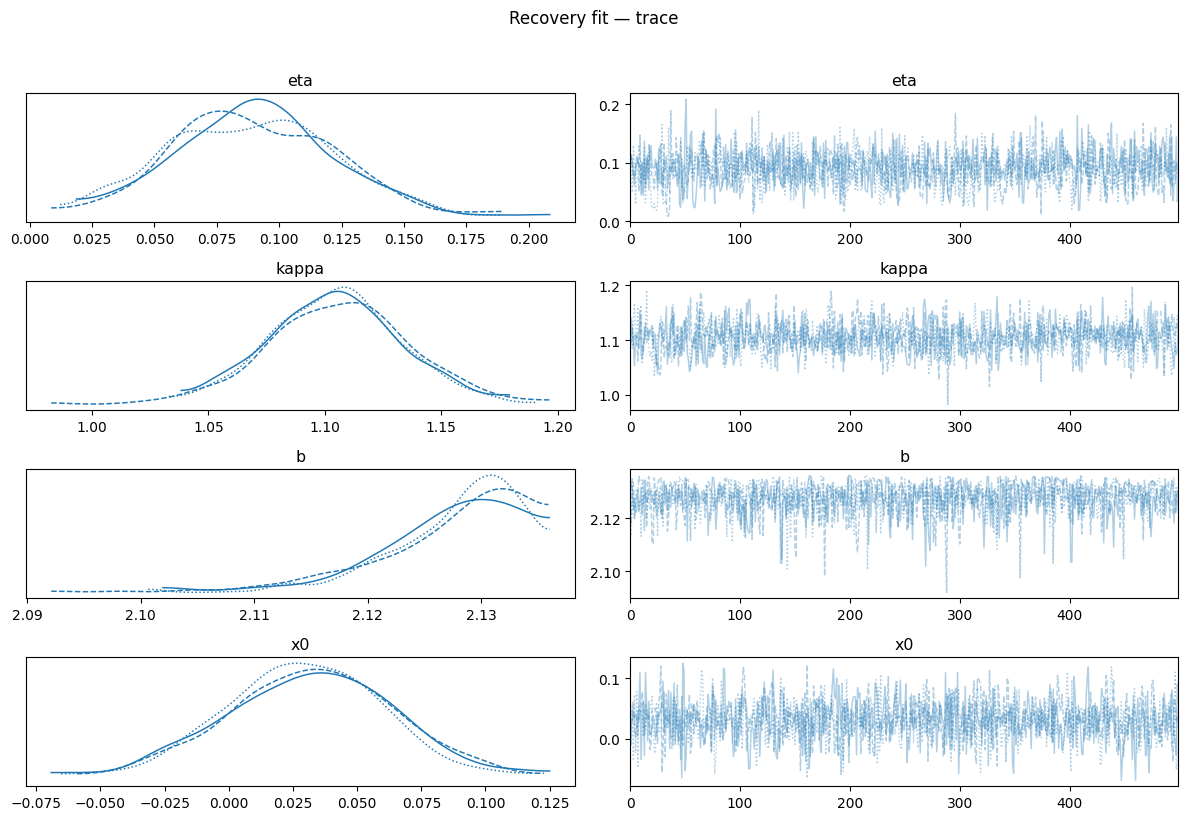

In [12]:
# Trace plots
az.plot_trace(trace_sim, var_names=params)
plt.suptitle("Recovery fit — trace", y=1.02)
plt.tight_layout()
plt.show()

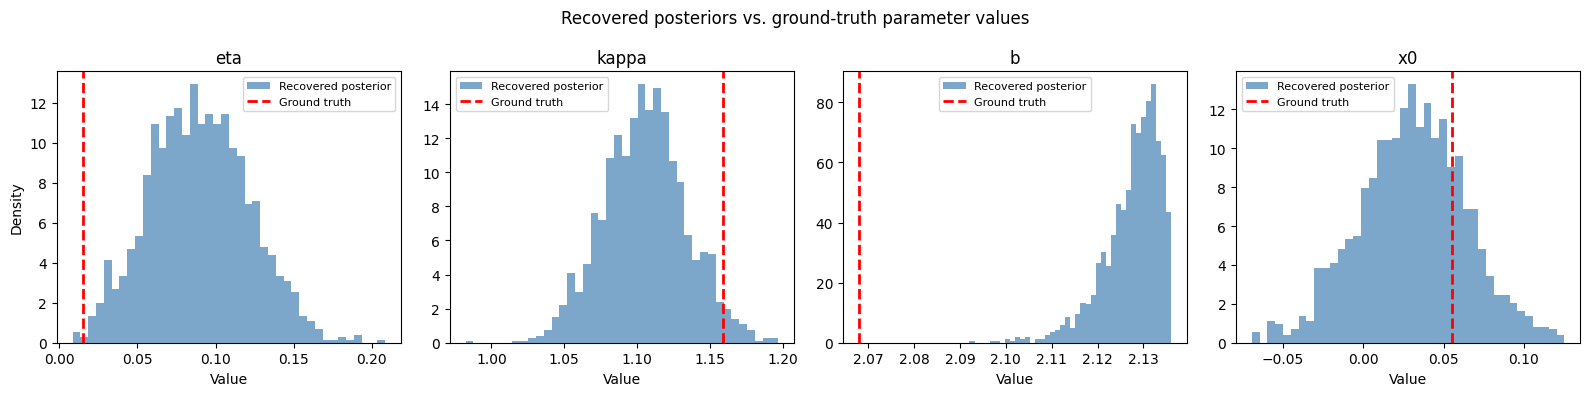

In [13]:
# Posterior vs. ground truth: one panel per parameter
fig, axes = plt.subplots(1, len(params), figsize=(4 * len(params), 4))

for ax, p in zip(axes, params):
    samples = trace_sim.posterior[p].values.flatten()
    ax.hist(samples, bins=40, density=True, alpha=0.7, color='steelblue', label='Recovered posterior')
    ax.axvline(TRUE_PARAMS[p], color='red', linewidth=2, linestyle='--', label='Ground truth')
    ax.set_title(p)
    ax.set_xlabel('Value')
    if ax is axes[0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle("Recovered posteriors vs. ground-truth parameter values", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Quantitative recovery summary
print(f"{'Parameter':>10s}  {'Ground truth':>14s}  {'Recovered mean':>14s}  {'Recovered 94% HDI':>22s}  {'Bias':>10s}")
print("-" * 80)

for p in params:
    samples = trace_sim.posterior[p].values.flatten()
    rec_mean = float(np.mean(samples))
    hdi = az.hdi(samples, hdi_prob=0.94)
    bias = rec_mean - TRUE_PARAMS[p]
    print(f"{p:>10s}  {TRUE_PARAMS[p]:>14.6f}  {rec_mean:>14.6f}"
          f"  [{hdi[0]:>9.6f}, {hdi[1]:>9.6f}]  {bias:>+10.6f}")

 Parameter    Ground truth  Recovered mean       Recovered 94% HDI        Bias
--------------------------------------------------------------------------------
       eta        0.015413        0.089516  [ 0.029814,  0.147473]   +0.074103
     kappa        1.158869        1.105248  [ 1.047947,  1.154404]   -0.053621
         b        2.067908        2.127535  [ 2.116540,  2.136000]   +0.059627
        x0        0.055326        0.030914  [-0.030249,  0.095281]   -0.024412


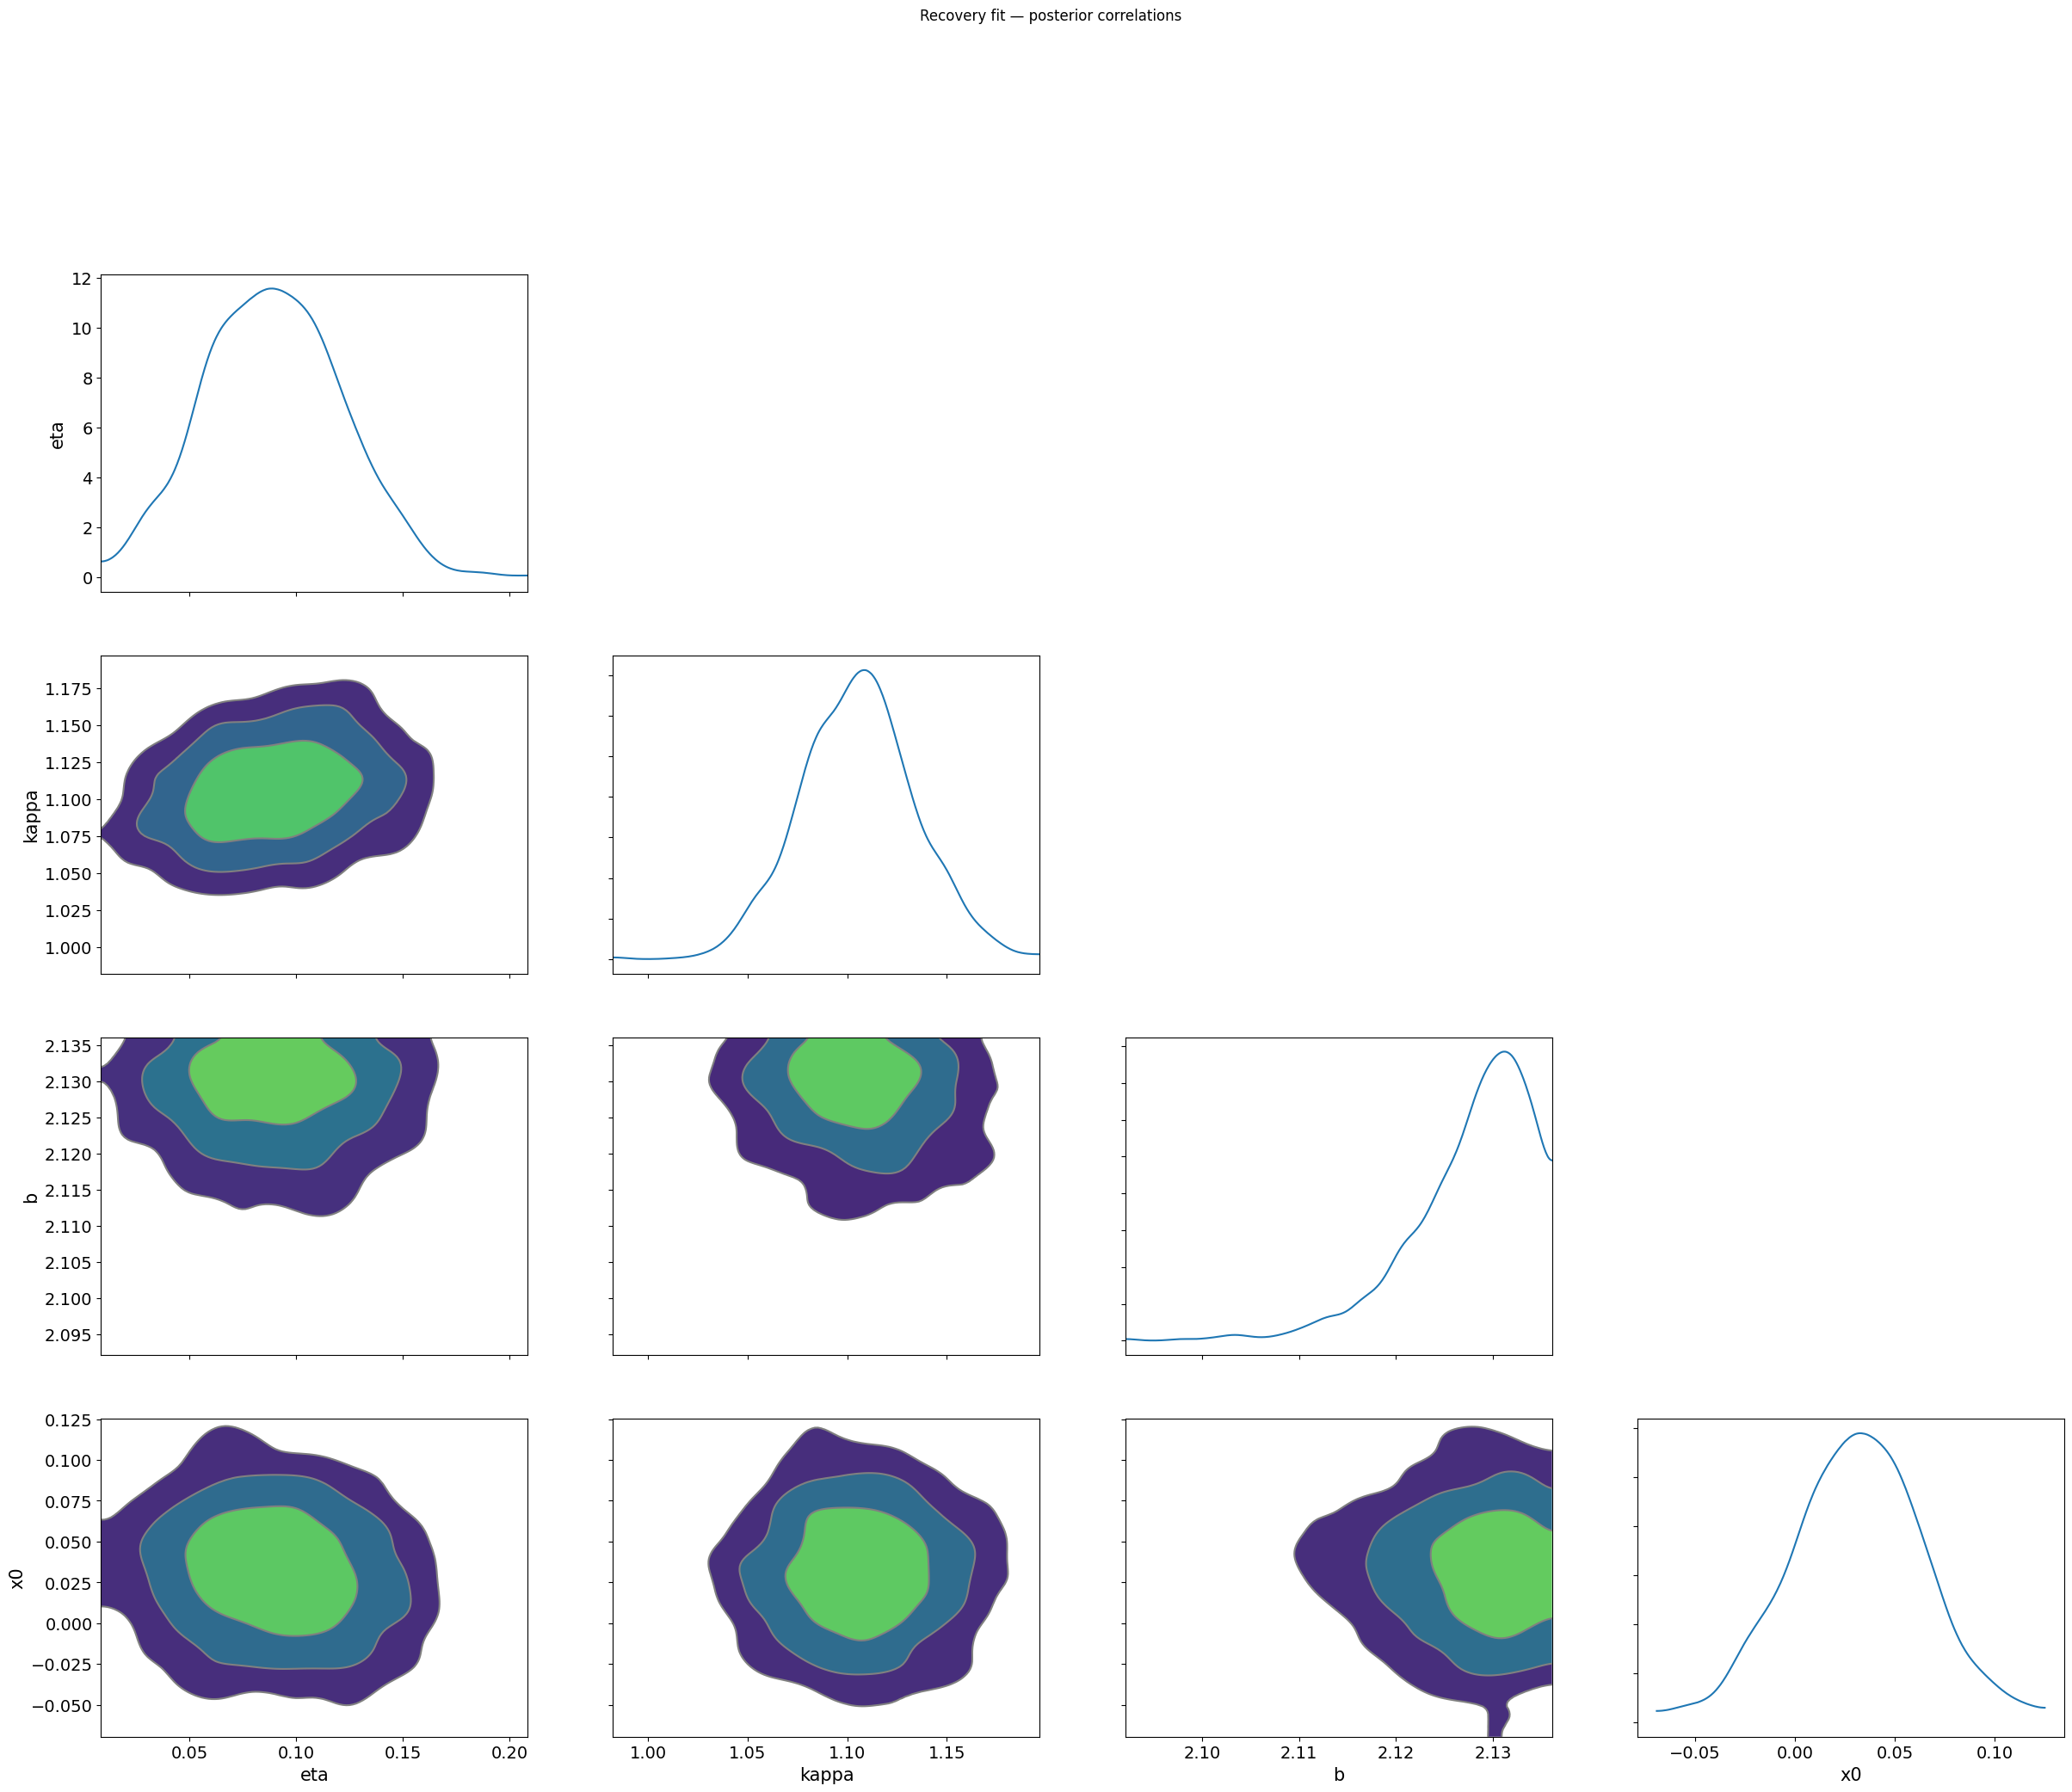

In [15]:
# Posterior pair plot
az.plot_pair(trace_sim, var_names=params, kind='kde', marginals=True)
plt.suptitle("Recovery fit — posterior correlations", y=1.02)
plt.show()

In [17]:
# Forward simulate from posterior means using the new trace 

eta_sim   = float(trace_sim.posterior['eta'].mean())
# eta_sim = 1.5
# eta_sim = 1.0
kappa_sim = float(trace_sim.posterior['kappa'].mean())
# kappa_sim = 1.03
# kappa_sim = 0.5
a_sim = 3.0
# a_sim     = float(trace_sim.posterior['a'].mean())
b_sim     = float(trace_sim.posterior['b'].mean())
# b_sim = TRUE_PARAMS['b']
x0_sim    = float(trace_sim.posterior['x0'].mean())

r1  = data_emp['r1']
r2  = data_emp['r2']
sacc         = data_emp['sacc']
length_data  = data_emp['length_data']
flag_data    = data_emp['flag_data']
n_trials     = len(r1)

# Build per-trial drift arrays
mu1_sim = kappa_sim * (r1 - eta_sim * r2)
mu2_sim = kappa_sim * (eta_sim * r1 - r2)
mu_data_sim = _build_mu_data_padded(
    mu1_sim.astype(np.float64),
    mu2_sim.astype(np.float64),
    length_data, flag_data, max_d,
)

# Budget Gaussian draws up to boundary-collapse time
max_t = float(data_emp['rt'].max()) + 1.0
budget_time  = min(a_t / b_t, max_t) if b_t > 0 else max_t
budget_steps = int(budget_time / SIM_DT) + 1

rng = np.random.default_rng(SIM_SEED)
gaussian_data = np.ascontiguousarray(
    rng.standard_normal((n_trials, budget_steps)), dtype=np.float64
)

print(f"Simulating {n_trials} trials  (budget_time={budget_time:.3f}s, steps={budget_steps})")

rt_sim_new, choice_sim_new = simulate_addm_batch_cy(
    np.ascontiguousarray(mu_data_sim),
    np.ascontiguousarray(sacc),
    np.ascontiguousarray(length_data),
    sigma, a_sim, b_sim, x0_sim,
    SIM_DT, budget_time,
    gaussian_data,
)
rt_sim_new     = np.array(rt_sim_new)
choice_sim_new = np.array(choice_sim_new)


Simulating 587 trials  (budget_time=1.455s, steps=14547)


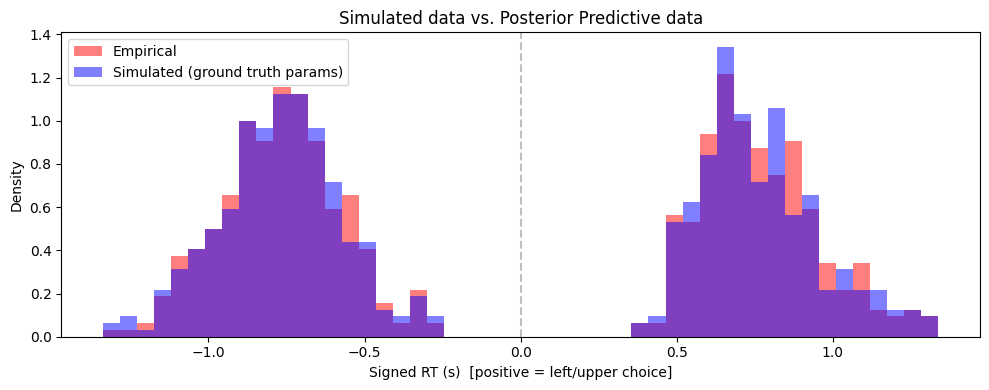

In [18]:
emp_signed = rt_sim_new*choice_sim_new
sim_signed = sim_rt[terminated] * sim_choice[terminated]

xmax = max(np.abs(emp_signed).max(), np.abs(sim_signed).max())
bins = np.linspace(-xmax, xmax, 50)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(emp_signed, bins=bins, density=True, alpha=0.5, color='red',  label='Empirical')
ax.hist(sim_signed, bins=bins, density=True, alpha=0.5, color='blue', label='Simulated (ground truth params)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Signed RT (s)  [positive = left/upper choice]')
ax.set_ylabel('Density')
ax.set_title('Simulated data vs. Posterior Predictive data')
ax.legend()
plt.tight_layout()
plt.show()